# TAXA-Net Demo

Forecast global horizontal irradiance (GHI, W/m²) using historical GHI and ground-based meteorological observations. Run all cells sequentially to evaluate the pretrained model and display an example forecast.

### 1. Compute Device
Detect available hardware (CUDA GPU with CPU fallback).

In [1]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Compute Device: {device}")

Compute Device: cuda


### 2. Load Sample Data & Input Format
Load preprocessed Alice Springs observations from June 2015, within the test period, as three input tensors and one target tensor:
- `x_en` $[B, 480, 1]$: Historical 5-day GHI observations (endogenous sequence)
- `x_ex` $[B, 480, 4]$: Wind speed, air temperature, relative humidity, and rainfall
- `x_time` $[B, 480, 4]$: Cyclic time-of-day and day-of-year features computed from the corresponding timestamps
- `y` $[B, 96]$: Next 24-hour ground-truth GHI (forecast target)

In [2]:
from config import DATA_PATH, SEQ_LEN, PRED_LEN, STRIDE, BATCH_SIZE, ENDO_COLS, EXO_COLS
from utils.dataset import build_demo_dataloader

dataset, dataloader = build_demo_dataloader(
    DATA_PATH, SEQ_LEN, PRED_LEN, STRIDE, BATCH_SIZE,
    endo_cols=ENDO_COLS, exo_cols=EXO_COLS
)
print(f"Loaded {len(dataset):,} sliding windows from {DATA_PATH}")

Loaded 2,305 sliding windows from data/sample_as_15min.csv


### 3. Load Pretrained TAXA-Net
Load `taxa_as_h96.pth` (386,592 parameters), trained on GHI and meteorological observations from the DKASC Alice Springs site from December 2011 to November 2014. The validation period is December 2014–May 2015, and the test period is June 2015–May 2016.

In [3]:
from config import CKPT_PATH, MODEL_CONFIG, ENDO_COLS, EXO_COLS
from models.taxa_net import TAXA_Net

model = TAXA_Net(SEQ_LEN, PRED_LEN, ENDO_COLS, EXO_COLS, **MODEL_CONFIG).to(device)
model.load_state_dict(torch.load(CKPT_PATH, map_location=device, weights_only=True))
model.eval()
print("TAXA-Net loaded successfully.")

TAXA-Net loaded successfully.


### 4. Evaluate Performance Metrics
Evaluate all supplied windows using RMSE, MAE, nRMSE, nMAE, and IA. RMSE and MAE are reported in W/m², while nRMSE and nMAE are normalised by the mean observed GHI.

Daytime metrics are computed only for observations with GHI > 10 W/m²; nighttime data remain in the dataset.

In [4]:
import numpy as np
from utils.metrics import print_metrics_table

preds, trues = [], []
with torch.no_grad():
    for b_en, b_ex, b_time, b_y in dataloader:
        preds.append(model(b_en.to(device), b_ex.to(device), b_time.to(device)).cpu().numpy())
        trues.append(b_y.numpy())

print_metrics_table(np.concatenate(trues), np.concatenate(preds), show_points=False)

--------------------------------------------------------------------------------------------
Scope                   |       nRMSE |       nMAE |       IA |  RMSE (W/m²) |  MAE (W/m²) |
--------------------------------------------------------------------------------------------
All-time (24h)          |      0.4043 |     0.1819 |   0.9794 |        70.73 |       31.82 |
Daytime (GHI > 10 W/m²) |      0.2689 |     0.1692 |   0.9441 |       106.89 |       67.25 |
--------------------------------------------------------------------------------------------


### 5. Visualize a Sample Forecast
Generate a 24-hour forecast on the selected sample window and plot against historical inputs and ground truth.

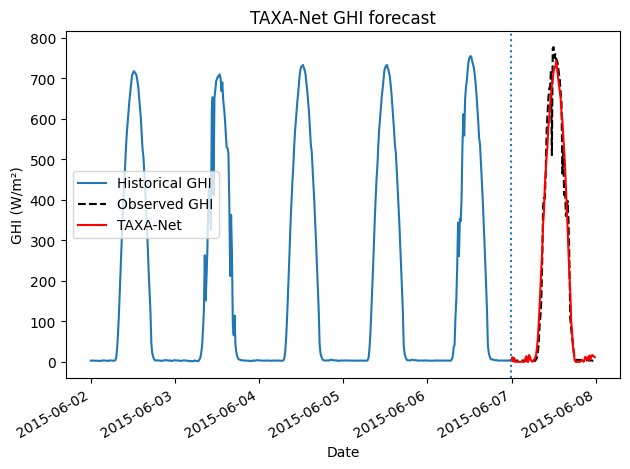

In [18]:
sample_idx = 96

from utils.visualization import plot_sample_forecast

sample_en, sample_ex, sample_time, sample_y = dataset[sample_idx]
with torch.no_grad():
    pred = model(sample_en.unsqueeze(0).to(device),
                 sample_ex.unsqueeze(0).to(device),
                 sample_time.unsqueeze(0).to(device))

plot_sample_forecast(sample_en.unsqueeze(0), sample_y.unsqueeze(0), pred, timestamps=dataset.get_timestamps(sample_idx))